In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from config import PROJECT_FOLDER, CITY_NAME

output_folder = os.path.join(PROJECT_FOLDER, "outputs")
table_folder = os.path.join(output_folder, "tables")
figure_folder = os.path.join(output_folder, "figures")

os.makedirs(figure_folder, exist_ok=True)

results_csv = os.path.join(table_folder, "tract_heat_equity_results.csv")
analysis_df = pd.read_csv(results_csv, dtype={"GEOID": str})

# Correlation table

In [32]:
fields = [
    "mean_lst_c",
    "mean_tree_canopy_pct",
    "median_income",
    "pct_black",
    "pct_hispanic",
    "pct_poverty",
    "pct_bachelors"
]

corr_table = analysis_df[fields].corr()

corr_csv = os.path.join(table_folder, "correlation_table.csv")
corr_table.to_csv(corr_csv)

corr_table

,mean_lst_c,mean_tree_canopy_pct,median_income,pct_black,pct_hispanic,pct_poverty,pct_bachelors
mean_lst_c,1.000000,-0.662098,-0.188789,-0.010385,0.293924,0.192619,-0.433686
mean_tree_canopy_pct,-0.662098,1.000000,0.318132,-0.205978,-0.367837,-0.277617,0.465894
median_income,-0.188789,0.318132,1.000000,-0.323312,-0.562828,-0.690499,0.625101
pct_black,-0.010385,-0.205978,-0.323312,1.000000,0.157165,0.348773,-0.288366
pct_hispanic,0.293924,-0.367837,-0.562828,0.157165,1.000000,0.563160,-0.818368
pct_poverty,0.192619,-0.277617,-0.690499,0.348773,0.563160,1.000000,-0.564433
pct_bachelors,-0.433686,0.465894,0.625101,-0.288366,-0.818368,-0.564433,1.000000


# Clean plotting dataframe

In [33]:
plot_df = analysis_df.copy()

plot_df["median_income"] = pd.to_numeric(plot_df["median_income"], errors="coerce")
plot_df["mean_lst_c"] = pd.to_numeric(plot_df["mean_lst_c"], errors="coerce")
plot_df["mean_tree_canopy_pct"] = pd.to_numeric(plot_df["mean_tree_canopy_pct"], errors="coerce")

plot_df = plot_df[
    (plot_df["median_income"] > 0) &
    (plot_df["median_income"] < 300000)
]

plot_df = plot_df.dropna(subset=["median_income", "mean_lst_c"])

# Income vs LST scatter plot

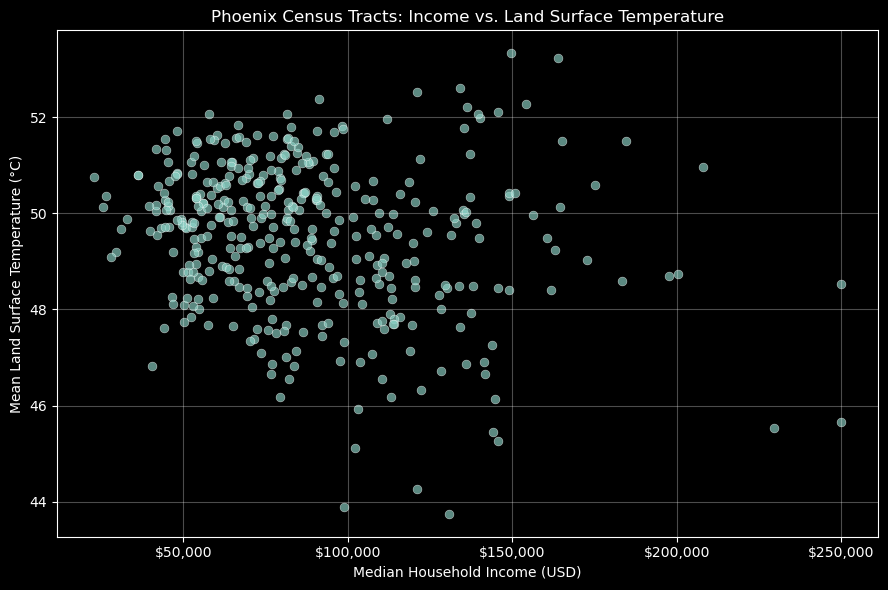

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    plot_df["median_income"],
    plot_df["mean_lst_c"],
    s=40,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4
)

ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

ax.set_xlabel("Median Household Income (USD)")
ax.set_ylabel("Mean Land Surface Temperature (°C)")
ax.set_title(f"{CITY_NAME} Census Tracts: Income vs. Land Surface Temperature")
ax.grid(alpha=0.3)

plt.tight_layout()

plot_path = os.path.join(figure_folder, "income_vs_lst_cleaned.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

# Tree canopy vs LST scatter plot

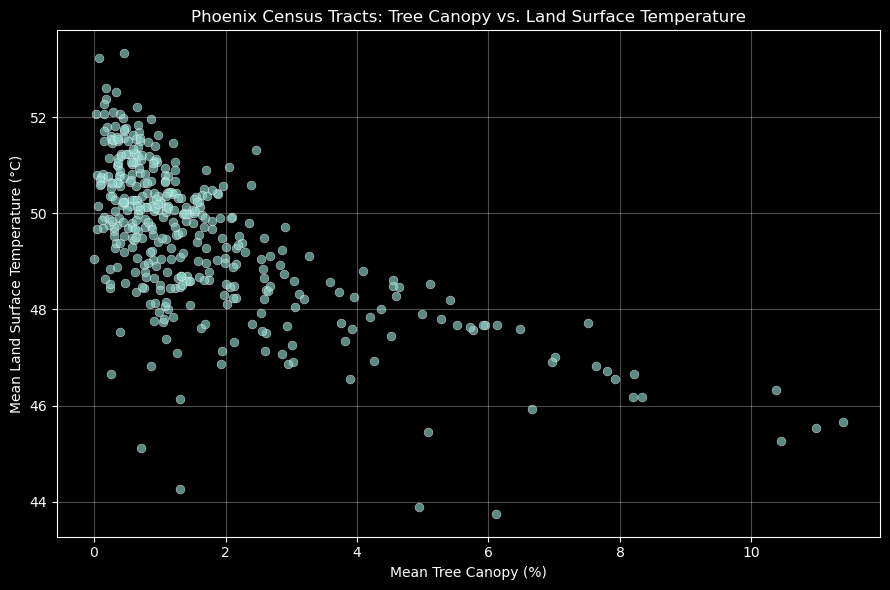

In [35]:
plot_df2 = analysis_df.copy()

plot_df2["mean_tree_canopy_pct"] = pd.to_numeric(plot_df2["mean_tree_canopy_pct"], errors="coerce")
plot_df2["mean_lst_c"] = pd.to_numeric(plot_df2["mean_lst_c"], errors="coerce")

plot_df2 = plot_df2.dropna(subset=["mean_tree_canopy_pct", "mean_lst_c"])

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    plot_df2["mean_tree_canopy_pct"],
    plot_df2["mean_lst_c"],
    s=40,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4
)

ax.set_xlabel("Mean Tree Canopy (%)")
ax.set_ylabel("Mean Land Surface Temperature (°C)")
ax.set_title(f"{CITY_NAME} Census Tracts: Tree Canopy vs. Land Surface Temperature")
ax.grid(alpha=0.3)

plt.tight_layout()

plot_path = os.path.join(figure_folder, "tree_canopy_vs_lst.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()